<a href="https://colab.research.google.com/github/andryowiniciusac-creator/learning-course-linea/blob/main/Aula_3_SQL_Numpy_e_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a class="anchor" id="top"></a>
# Aula 3 - Acesso a dados pelo LIneA Science Server, Pandas DataFrame
  

<a class="anchor" id="sql"></a>
# 1. SQL básico

Para exemplificar a leitura de dados a partir de um Jupyter Notebook, vamos criar um arquivo com dados baixados da ferramenta **User Query** da plataforma [LIneA Science Server](https://desportal2.cosmology.illinois.edu).


```sql

SELECT coadd_object_id, ra ,dec, mag_auto_g, mag_auto_r, mag_auto_i, magerr_auto_g, magerr_auto_r, magerr_auto_i, flags_i
FROM DES_ADMIN.DR2_MAIN
WHERE ra > 35 and ra < 36
AND dec > -10 and dec < -9
AND mag_auto_g between 15 and 23
AND CLASS_STAR_G < 0.5
AND FLAGS_I <=4
```



Os dados acessados pelo Science Server estão hospedados nos computadores do NCSA. Faremos o download deste subconjunto de dados no formato _comma-separated values_ (CSV) e em seguida o upload do arquivo gerado para o JupyterHub. Sugerimos nomear o arquivo como `galaxias.csv` e guardá-lo dentro da pasta `dados`.  

Nas células abaixo vamos demonstrar como ler/escrever arquivos e manipular dados usando duas bibliotecas diferentes. As células do tipo **Markdown** contém instruções.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

caminho_do_arquivo = "/content/drive/MyDrive/Exemplo1_Aula3.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<a class="anchor" id="numpy"></a>
## 3. Manipulação dos dados usando NumPy

Documentação da biblioteca NumPy:  https://numpy.org/doc/stable/index.html



Importação do Numpy

In [1]:
import numpy as np
print('NumPy version: ', np.__version__)

NumPy version:  2.0.2


Leitura do arquivo, atribuindo todo o seu conteúdo a uma variável usando a função `loadtxt`([doc](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html)):


In [2]:
tabela = np.loadtxt("/content/drive/MyDrive/2026-06-08-19-36-42-653799.csv", delimiter=",", skiprows=1 )
tabela
# Lembrando que o foco são galáxias
# delimiter só separa os valores com ","
# skiprows pula 1 linha, pois a primeira linha do arquivo contém um cabeçalho

array([[ 1.26801214e+09,  3.50096920e+01, -9.98131000e+00, ...,
         1.68670863e-02,  1.54460492e-02,  3.00000000e+00],
       [ 1.26801063e+09,  3.50118770e+01, -9.98102200e+00, ...,
         1.02584751e-03,  1.19273015e-03,  2.00000000e+00],
       [ 1.26801309e+09,  3.50263830e+01, -9.99203800e+00, ...,
         3.17077301e-02,  4.28004935e-02,  0.00000000e+00],
       ...,
       [ 1.27129296e+09,  3.59859560e+01, -9.00100900e+00, ...,
         1.80967860e-02,  1.45398621e-02,  3.00000000e+00],
       [ 1.27129380e+09,  3.57264940e+01, -9.00841800e+00, ...,
         1.36151602e-02,  1.80943534e-02,  0.00000000e+00],
       [ 1.27129299e+09,  3.57940720e+01, -9.00032300e+00, ...,
         3.06447893e-02,  4.13357243e-02,  2.00000000e+00]])

Conferindo o tipo de objeto.

In [7]:
type(tabela) # Array de n dimensões, ndarray

numpy.ndarray

Consultando o tipo de dados dos elementos contidos no array.

In [18]:
tabela.dtype
# Mesmo que tenha int na tabela, o numpy transforma tudo automaticamente para float
# Isso ocorre pois os arrays são homogêneos nos tipos de dados

dtype('float64')

Consultando as dimensões do array (linhas,colunas).

In [8]:
tabela.shape

(8303, 10)

Usando o argumento `unpack` da função `loadtxt` para obter as colunas separadamente. Quando ativado, o argumento `unpack` traz a tabela transposta.

In [14]:
tabela_unpack = np.loadtxt \
 ("/content/drive/MyDrive/2026-06-08-19-36-42-653799.csv", delimiter=",", \
  skiprows=1, unpack=True)

In [11]:
tabela_unpack.shape

(10, 8303)

Sabendo a ordem das colunas, podemos atribuir cada uma delas a uma variável. Dica: pegar os nomes do cabeçalho do arquivo.

In [12]:
coadd_object_id, ra ,dec, mag_auto_g, mag_auto_r, mag_auto_i, \
magerr_auto_g, magerr_auto_r, magerr_auto_i, flags_i = tabela_unpack
# Cada coluna = 1 variável

In [13]:
coadd_object_id

array([1.26801214e+09, 1.26801063e+09, 1.26801309e+09, ...,
       1.27129296e+09, 1.27129380e+09, 1.27129299e+09])

Podemos fazer isso direto ao ler o arquivo. OBS: ao usar os mesmos nomes para as variáveis, está sobrescrevendo as anteriores.

In [3]:
coadd_object_id, ra ,dec, mag_auto_g, mag_auto_r, mag_auto_i, \
magerr_auto_g, magerr_auto_r, magerr_auto_i, flags_i = np.loadtxt \
 ("/content/drive/MyDrive/2026-06-08-19-36-42-653799.csv", delimiter=",", \
  skiprows=1, unpack=True)

In [4]:
flags_i

array([3., 2., 0., ..., 3., 0., 2.])

Fazendo um filtro (ou máscara) para galáxias brilhantes (mag i < 20).

In [5]:
mask = (mag_auto_i < 20)
mask
# Filtramos apenas linhas que tem na coluna mag_auto_i valores < 20
# Mas não filtramos apenas a coluna mag_auto_i
# Também filtramos outras linhas que tem essa condição

array([False,  True, False, ..., False, False, False])

Conferindo o tamanho do array **sem** filtro.

In [7]:
len(mag_auto_i)

8303

Conferindo o tamanho do array **com** filtro.

In [8]:
len(mag_auto_i[mask])

1825

A "máscara" (ou filtro) tambem pode ser aplicada a qualquer outro array com as mesmas dimensões. Teste com outra coluna.

In [9]:
ra[mask]

array([35.011877, 35.091979, 35.002781, ..., 35.957403, 35.960482,
       35.964772])

A máscara é útil para criar um subconjunto dos dados. Criando um subconjunto com 3 colunas e com as linhas que satisfazem a condição do filtro.  

In [10]:
subset_tabela = np.array ([coadd_object_id[mask], mag_auto_i[mask], magerr_auto_i[mask]])
# Salvo na memória

Salvando este subconjunto em um arquivo usando a função `savetxt`.

In [15]:
# pra ler: loadtxt(); pra salvar/escrever: savetxt()
np.savetxt("subset_galaxias.csv", subset_tabela.T)
# Criamos um array chamado subset_galaxias_csv com dados do subset_tabela

Dando uma ohada no arquivo salvo (duplo clique no arquivo leva para o visualizador de tabelas).

Algo de errado com o número de linhas?

In [16]:
np.savetxt("subset_galaxias.csv", subset_tabela.T)

E agora? Algo errado com o número de colunas?

In [17]:
np.savetxt("subset_galaxias.csv", subset_tabela.T, delimiter=",")
# T de transposta e delimiter para separar as colunas, para não ficar tudo junto

Como ficou a formatação? Que tal deixar mais legível e definir o número de espaços?

In [22]:
# Como Default, está tudo em notação científica
np.savetxt("subset_galaxias.csv", subset_tabela.T, delimiter=",", fmt=["%12d", "%10.4f", "%10.4f"])
# Pra formatar, usamos o argumento fmt
# Como são 3 colunas, precisa de uma lista com 3 formatos
# O formato a gente põe em strings com %
# A primeira coluna era o identificador, um int, então colocamos d,
# A segunda e a terceira são floats, então escolhemos 4 casas decimais

Que tal um cabeçalho para nomear as colunas?

In [23]:
np.savetxt("subset_galaxias.csv", subset_tabela.T, delimiter=",", fmt=["%12d", "%10.4f", "%10.4f"], header="objects id, mag i, err i")

Fizemos a leitura e a escrita desses dados usando numpy

<a class="anchor" id="numpy"></a>
# 4. Manipulação dos dados usando Pandas

Vamos fazer a mesma coisa usando pandas e mais algumas funcionalidades

Documentação da biblioteca Pandas: https://pandas.pydata.org/docs/

In [24]:
import pandas as pd
print('Pandas version: ', pd.__version__)

Pandas version:  2.2.2


Vamos trabalhar com 2 tipos de objetos no Pandas: Series e DataFrames

Series é análoga ao array de uma dimensão; como se fosse uma lista com outras propriedades

DataFrame é como se fosse uma tabela com muito mais propriedades; você tem várias colunas, várias Series dentro do mesmo objeto

### Pandas Series

https://pandas.pydata.org/docs/reference/api/pandas.Series.html

### Pandas DataFrame
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

```python
class pandas.DataFrame(data=None, index=None, columns=None, dtype=None, copy=None)
```

_"Two-dimensional, size-mutable, potentially heterogeneous tabular data. <p>
Data structure also contains labeled axes (rows and columns). Arithmetic operations align on both row and column labels. Can be thought of as a dict-like container for Series objects. The primary pandas data structure."_



Exemplo de criação de um DataFrame a partir de um dicionário:

In [22]:
dic = {"nomes": ["Huguinho", "Zezinho", "Luizinho"], # Lista de nomes
       "cores": ["vermelho", "verde", "azul"], # Lista de cores
       "características": ["nerd", "aventureiro", "criativo"]} # Lista de características
# Criamos um dicionário com 3 chaves: nomes, cores, características
# Em cada chave tem uma lista

In [23]:
sobrinhos = pd.DataFrame(dic)
sobrinhos
# Cria uma estrutura de dados organizada em colunas que respeita uma ordem (índice); no Python começa com 0
# Você pode criar um DataFrame a partir de um dicionário

,nomes,cores,características
0,Huguinho,vermelho,nerd
1,Zezinho,verde,aventureiro
2,Luizinho,azul,criativo


Um DataFrame também é o resultado da leitura de uma tabela usando a função `read_csv` do Pandas.

In [26]:
# Também é possível criar um dicionário a partir da leitura
# É como se tivesse extraindo do arquivo um dicionário, onde as chaves são as colunas
# Daí vem a importância de dar um cabeçalho para aquela tabela de antes
# Usaremos esse cabeçalho como chaves para nosso exemplo

dados = pd.read_csv("/content/drive/MyDrive/2026-06-08-19-36-42-653799.csv")
dados

,coadd_object_id,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
0,1268012143,35.009692,-9.981310,22.669477,21.461973,20.809364,0.038939,0.016867,0.015446,3
1,1268010633,35.011877,-9.981022,17.691729,16.781013,16.404503,0.001839,0.001026,0.001193,2
2,1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0
3,1268013356,35.030463,-9.996026,22.360167,21.553864,21.298775,0.038582,0.022318,0.030390,0
4,1268013449,35.057247,-9.998645,22.974100,21.287172,20.514681,0.103210,0.026253,0.021879,0
...,...,...,...,...,...,...,...,...,...,...
8298,1271294982,35.996844,-9.020742,22.689247,22.084867,21.879074,0.037061,0.027905,0.040031,0
8299,1271293118,35.964772,-9.003737,21.480431,20.135656,19.695646,0.017894,0.006893,0.007797,2
8300,1271292961,35.985956,-9.001009,22.895008,21.229866,20.411856,0.063292,0.018097,0.014540,3
8301,1271293799,35.726494,-9.008418,21.902758,20.967194,20.622946,0.025865,0.013615,0.018094,0


Explorando algumas funções e atributos úteis de um objeto to tipo _DataFrame_, começando pela sua "ficha técnica".

In [27]:
dados.info()
# É possível ver os nomes das colunas (Column), ...
# a quantidade de dados (linhas) em cada uma delas (Non-Null Count), ...
# O tipo de dado (Dtype, data type eu acho).
# Percebe-se que o Pandas respeita o tipo de dado, diferentemente de arrays

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8303 entries, 0 to 8302
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   coadd_object_id  8303 non-null   int64  
 1   ra               8303 non-null   float64
 2   dec              8303 non-null   float64
 3   mag_auto_g       8303 non-null   float64
 4   mag_auto_r       8303 non-null   float64
 5   mag_auto_i       8303 non-null   float64
 6   magerr_auto_g    8303 non-null   float64
 7   magerr_auto_r    8303 non-null   float64
 8   magerr_auto_i    8303 non-null   float64
 9   flags_i          8303 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 648.8 KB


Imprimindo as primeiras linhas.

In [28]:
dados.head() # Ele imprime por Default 5 linhas

,coadd_object_id,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
0,1268012143,35.009692,-9.981310,22.669477,21.461973,20.809364,0.038939,0.016867,0.015446,3
1,1268010633,35.011877,-9.981022,17.691729,16.781013,16.404503,0.001839,0.001026,0.001193,2
2,1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0
3,1268013356,35.030463,-9.996026,22.360167,21.553864,21.298775,0.038582,0.022318,0.030390,0
4,1268013449,35.057247,-9.998645,22.974100,21.287172,20.514681,0.103210,0.026253,0.021879,0


Definindo o número de linhas exibidas.

In [29]:
dados.head(3)

,coadd_object_id,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
0,1268012143,35.009692,-9.981310,22.669477,21.461973,20.809364,0.038939,0.016867,0.015446,3
1,1268010633,35.011877,-9.981022,17.691729,16.781013,16.404503,0.001839,0.001026,0.001193,2
2,1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0


Imprimindo as últimas linhas.

In [30]:
dados.tail()

,coadd_object_id,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
8298,1271294982,35.996844,-9.020742,22.689247,22.084867,21.879074,0.037061,0.027905,0.040031,0
8299,1271293118,35.964772,-9.003737,21.480431,20.135656,19.695646,0.017894,0.006893,0.007797,2
8300,1271292961,35.985956,-9.001009,22.895008,21.229866,20.411856,0.063292,0.018097,0.014540,3
8301,1271293799,35.726494,-9.008418,21.902758,20.967194,20.622946,0.025865,0.013615,0.018094,0
8302,1271292994,35.794072,-9.000323,22.884432,21.858841,21.453714,0.065469,0.030645,0.041336,2


Renomeando a coluna `coadd_object_id`

In [31]:
dados.rename(columns={"coadd_object_id":"ID"})

,ID,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
0,1268012143,35.009692,-9.981310,22.669477,21.461973,20.809364,0.038939,0.016867,0.015446,3
1,1268010633,35.011877,-9.981022,17.691729,16.781013,16.404503,0.001839,0.001026,0.001193,2
2,1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0
3,1268013356,35.030463,-9.996026,22.360167,21.553864,21.298775,0.038582,0.022318,0.030390,0
4,1268013449,35.057247,-9.998645,22.974100,21.287172,20.514681,0.103210,0.026253,0.021879,0
...,...,...,...,...,...,...,...,...,...,...
8298,1271294982,35.996844,-9.020742,22.689247,22.084867,21.879074,0.037061,0.027905,0.040031,0
8299,1271293118,35.964772,-9.003737,21.480431,20.135656,19.695646,0.017894,0.006893,0.007797,2
8300,1271292961,35.985956,-9.001009,22.895008,21.229866,20.411856,0.063292,0.018097,0.014540,3
8301,1271293799,35.726494,-9.008418,21.902758,20.967194,20.622946,0.025865,0.013615,0.018094,0


In [32]:
# Mas ele não salva em outras células
dados

,coadd_object_id,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
0,1268012143,35.009692,-9.981310,22.669477,21.461973,20.809364,0.038939,0.016867,0.015446,3
1,1268010633,35.011877,-9.981022,17.691729,16.781013,16.404503,0.001839,0.001026,0.001193,2
2,1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0
3,1268013356,35.030463,-9.996026,22.360167,21.553864,21.298775,0.038582,0.022318,0.030390,0
4,1268013449,35.057247,-9.998645,22.974100,21.287172,20.514681,0.103210,0.026253,0.021879,0
...,...,...,...,...,...,...,...,...,...,...
8298,1271294982,35.996844,-9.020742,22.689247,22.084867,21.879074,0.037061,0.027905,0.040031,0
8299,1271293118,35.964772,-9.003737,21.480431,20.135656,19.695646,0.017894,0.006893,0.007797,2
8300,1271292961,35.985956,-9.001009,22.895008,21.229866,20.411856,0.063292,0.018097,0.014540,3
8301,1271293799,35.726494,-9.008418,21.902758,20.967194,20.622946,0.025865,0.013615,0.018094,0


In [34]:
dados.rename(columns={"coadd_object_id":"ID"}, inplace=True)

In [35]:
dados

,ID,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
0,1268012143,35.009692,-9.981310,22.669477,21.461973,20.809364,0.038939,0.016867,0.015446,3
1,1268010633,35.011877,-9.981022,17.691729,16.781013,16.404503,0.001839,0.001026,0.001193,2
2,1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0
3,1268013356,35.030463,-9.996026,22.360167,21.553864,21.298775,0.038582,0.022318,0.030390,0
4,1268013449,35.057247,-9.998645,22.974100,21.287172,20.514681,0.103210,0.026253,0.021879,0
...,...,...,...,...,...,...,...,...,...,...
8298,1271294982,35.996844,-9.020742,22.689247,22.084867,21.879074,0.037061,0.027905,0.040031,0
8299,1271293118,35.964772,-9.003737,21.480431,20.135656,19.695646,0.017894,0.006893,0.007797,2
8300,1271292961,35.985956,-9.001009,22.895008,21.229866,20.411856,0.063292,0.018097,0.014540,3
8301,1271293799,35.726494,-9.008418,21.902758,20.967194,20.622946,0.025865,0.013615,0.018094,0


Usando a coluna coadd_object_id IDs como índice no DataFrame.

In [36]:
# É possível usar essa coluna como o próprio índice no DataFrame
dados.set_index("ID")

,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
ID,,,,,,,,,
1268012143,35.009692,-9.981310,22.669477,21.461973,20.809364,0.038939,0.016867,0.015446,3
1268010633,35.011877,-9.981022,17.691729,16.781013,16.404503,0.001839,0.001026,0.001193,2
1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0
1268013356,35.030463,-9.996026,22.360167,21.553864,21.298775,0.038582,0.022318,0.030390,0
1268013449,35.057247,-9.998645,22.974100,21.287172,20.514681,0.103210,0.026253,0.021879,0
...,...,...,...,...,...,...,...,...,...
1271294982,35.996844,-9.020742,22.689247,22.084867,21.879074,0.037061,0.027905,0.040031,0
1271293118,35.964772,-9.003737,21.480431,20.135656,19.695646,0.017894,0.006893,0.007797,2
1271292961,35.985956,-9.001009,22.895008,21.229866,20.411856,0.063292,0.018097,0.014540,3


In [37]:
# Novamente, ele não deixa isso permanente, então vamos lá:
dados.set_index("ID", inplace=True)

In [38]:
dados

,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
ID,,,,,,,,,
1268012143,35.009692,-9.981310,22.669477,21.461973,20.809364,0.038939,0.016867,0.015446,3
1268010633,35.011877,-9.981022,17.691729,16.781013,16.404503,0.001839,0.001026,0.001193,2
1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0
1268013356,35.030463,-9.996026,22.360167,21.553864,21.298775,0.038582,0.022318,0.030390,0
1268013449,35.057247,-9.998645,22.974100,21.287172,20.514681,0.103210,0.026253,0.021879,0
...,...,...,...,...,...,...,...,...,...
1271294982,35.996844,-9.020742,22.689247,22.084867,21.879074,0.037061,0.027905,0.040031,0
1271293118,35.964772,-9.003737,21.480431,20.135656,19.695646,0.017894,0.006893,0.007797,2
1271292961,35.985956,-9.001009,22.895008,21.229866,20.411856,0.063292,0.018097,0.014540,3


Imprimindo a descrição do _DataFrame_ (resumão com estatísticas básicas).

In [40]:
dados.describe() # Isso nos dá muita coisa
# count: quantos dados/linahas aquela Serie/coluna tem
# mean: média
# std: desvio padrão
# min: valor mínimo
# 25%: percentagem, os quartis
# 50%: ...
# 75%: ...
# max: valor máximo

,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
count,8303.000000,8303.000000,8303.000000,8303.000000,8303.000000,8303.000000,8303.000000,8303.000000,8303.000000
mean,35.506312,-9.500373,21.983469,21.113554,20.734628,0.040697,0.025814,0.033914,1.008792
std,0.286762,0.286478,0.976780,1.049115,1.092421,0.022985,0.019564,0.143672,1.292192
min,35.000128,-9.999571,15.452966,15.098738,14.776508,0.000366,0.000359,0.000423,0.000000
25%,35.257622,-9.745134,21.555292,20.578472,20.119426,0.022988,0.012184,0.013663,0.000000
50%,35.517416,-9.502468,22.281643,21.302000,20.902096,0.039447,0.021179,0.025173,0.000000
75%,35.756515,-9.253895,22.695095,21.871248,21.529256,0.055087,0.033989,0.042321,2.000000
max,35.999730,-9.000099,22.999998,23.906473,27.477474,0.188672,0.179308,12.871658,3.000000


Fazendo um filtro para selecionar objetos com fotometria perfeita (flags_i = 0).

In [41]:
# No numpy criamos uma máscara com colchetes [mask] e aplicávamos isso no array ID[mask], bandai[mask]
dados.query("flags_i == 0")

,ra,dec,mag_auto_g,mag_auto_r,mag_auto_i,magerr_auto_g,magerr_auto_r,magerr_auto_i,flags_i
ID,,,,,,,,,
1268013092,35.026383,-9.992038,22.710260,22.055099,21.790064,0.047667,0.031708,0.042800,0
1268013356,35.030463,-9.996026,22.360167,21.553864,21.298775,0.038582,0.022318,0.030390,0
1268013449,35.057247,-9.998645,22.974100,21.287172,20.514681,0.103210,0.026253,0.021879,0
1268012176,35.052773,-9.981950,22.751884,21.854773,21.688477,0.054026,0.029789,0.042765,0
1268011611,35.055386,-9.975287,22.802801,22.245192,21.906065,0.063444,0.049727,0.061002,0
...,...,...,...,...,...,...,...,...,...
1271294887,35.967437,-9.024147,22.640041,21.932695,21.670597,0.049684,0.034083,0.046513,0
1271295247,35.979297,-9.024211,22.272884,21.163136,20.813124,0.028511,0.013549,0.016970,0
1271294340,35.991354,-9.015094,22.572273,21.805824,20.966707,0.053676,0.034577,0.028405,0


Conferindo o tamanho do _DataFrame_ filtrado.

In [42]:
dados.query("flags_i == 0").count()

,0
ra,5006
dec,5006
mag_auto_g,5006
mag_auto_r,5006
mag_auto_i,5006
magerr_auto_g,5006
magerr_auto_r,5006
magerr_auto_i,5006
flags_i,5006


Comparando com o original.

In [43]:
dados.count() # Isso é bom para se testar/brincar com o GMT

,0
ra,8303
dec,8303
mag_auto_g,8303
mag_auto_r,8303
mag_auto_i,8303
magerr_auto_g,8303
magerr_auto_r,8303
magerr_auto_i,8303
flags_i,8303


Tratando dados qualitativos: flags de qualidade

In [46]:
# Do DataFrame, podemos acessar uma só Serie

dados["flags_i"] # Usando dicionários

,flags_i
ID,
1268012143,3
1268010633,2
1268013092,0
1268013356,0
1268013449,0
...,...
1271294982,0
1271293118,2
1271292961,3


In [47]:
dados.flags_i # A coluna pode virar atributo do objeto

,flags_i
ID,
1268012143,3
1268010633,2
1268013092,0
1268013356,0
1268013449,0
...,...
1271294982,0
1271293118,2
1271292961,3


In [48]:
type(dados.flags_i)

pandas.core.series.Series

Contando valores de cada categoria (cada flag).

In [49]:
dados.flags_i.value_counts()
# .value_counts() serve pra mostrar quantos dados tem com tais flags na banda i

,count
flags_i,
0,5006
3,1889
2,1301
1,107


A classe _Series_ possui alguns gráficos simples embutidos, por exemplo, o gráfico de barras (histograma).

<Axes: xlabel='flags_i'>

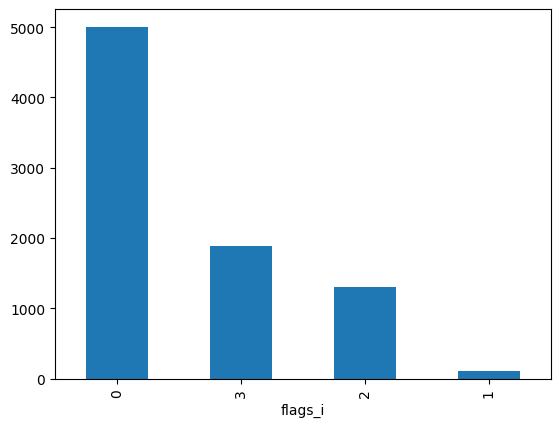

In [50]:
%matplotlib inline
dados.flags_i.value_counts().plot(kind="bar")

Gráfico de pizza:

<Axes: ylabel='count'>

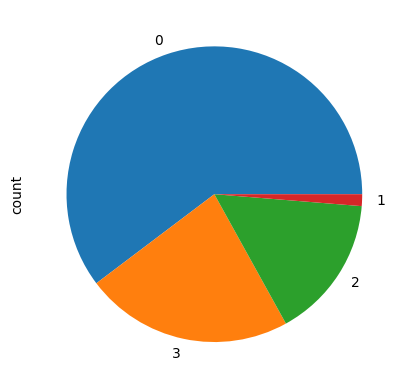

In [51]:
dados.flags_i.value_counts().plot(kind="pie")